<a href="https://colab.research.google.com/github/VenkatG-G/252_-project/blob/main/mobilenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from google.colab import drive


drive.mount('/content/drive')
ZIP_PATH = '/content/drive/MyDrive/archive.zip'
if not os.path.exists('Animals-10'):
    print(f"Copying {ZIP_PATH} to local storage...")
    !cp "{ZIP_PATH}" animals-10.zip
    print("Unzipping...")
    !unzip -q animals-10.zip -d Animals-10
    print("Done.")

DATA_DIR = 'Animals-10/raw-img'
if not os.path.exists(DATA_DIR):
    for root, dirs, files in os.walk('Animals-10'):
        if 'cane' in dirs:
            DATA_DIR = root
            break

class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Classes found: {class_names}")

image_paths = []
labels = []
class_to_index = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    for f in os.listdir(class_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(class_dir, f))
            labels.append(class_to_index[class_name])


X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


class_weights_arr = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

print(f"Data ready: {len(X_train)} train, {len(X_val)} val, {len(X_test)} test.")

Mounted at /content/drive
Copying /content/drive/MyDrive/archive.zip to local storage...
Unzipping...
Done.
Classes found: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Data ready: 18325 train, 3927 val, 3927 test.


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

def load_and_preprocess_mobilenet(image_path, label):
    """Loads, decodes, and preprocesses a single image for MobileNetV2."""

    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)

    return image, label

def build_dataset(image_paths, labels, is_training=False):
    """Builds a tf.data.Dataset pipeline."""
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if is_training:
        ds = ds.shuffle(buffer_size=len(image_paths), reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

train_ds = build_dataset(X_train, y_train, is_training=True)
val_ds = build_dataset(X_val, y_val, is_training=False)
test_ds = build_dataset(X_test, y_test, is_training=False)
y_test_true = np.array([y.numpy() for x, y in test_ds.unbatch()])

print("MobileNetV2 Data Pipeline Ready.")

MobileNetV2 Data Pipeline Ready.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


def build_mobilenet_model():

    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False


    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_mobilenet_model()

print("\n--- STAGE 1: WARM-UP ---")
model.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_1 = ModelCheckpoint('mobile_stage1.keras', save_best_only=True, monitor='val_loss')

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint_1]
)

print("\n--- STAGE 2: FINE-TUNING ---")
model.load_weights('mobile_stage1.keras')
model.layers[1].trainable = True

for layer in model.layers[1].layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_2 = ModelCheckpoint('mobile_best.keras', save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[checkpoint_2, early_stop]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- STAGE 1: WARM-UP ---
Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.6632 - loss: 1.0625 - val_accuracy: 0.9470 - val_loss: 0.1859
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9020 - loss: 0.3226 - val_accuracy: 0.9554 - val_loss: 0.1575
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.9189 - loss: 0.2700 - val_accuracy: 0.9534 - val_loss: 0.1582
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9228 - loss: 0.2429 - val_accuracy: 0.9570 - val_loss: 0.1473
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9223 - loss: 0.2410 - val_accuracy: 0.9598 - val_loss: 0.1400
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9262 - loss: 0.2380 - val_accuracy: 0.9608 - val_loss: 0.1379
Epoch 7/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9297 - loss: 0.2291 - val_accuracy: 0.9585 - val_loss: 0.1367
Epoch 8/10
28

In [ ]:
import time
from sklearn.metrics import classification_report, f1_score

model.load_weights('mobile_best.keras')


print("Running predictions...")
logits = model.predict(test_ds)
preds = np.argmax(logits, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, preds, target_names=class_names))
weighted_f1 = f1_score(y_test, preds, average='weighted')
print(f"Weighted F1-Score: {weighted_f1:.4f}")


total_params = model.count_params()
print(f"\n--- EFFICIENCY METRICS ---")
print(f"Total Parameters: {total_params:,}")


print("Measuring inference speed...")
start_time = time.time()

model.predict(test_ds)
end_time = time.time()

total_time = end_time - start_time
avg_time_per_image = (total_time / len(y_test)) * 1000

print(f"Total Inference Time (Test Set): {total_time:.2f} seconds")
print(f"Average Inference Time per Image: {avg_time_per_image:.2f} ms")

Running predictions...
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        cane       0.98      0.96      0.97       730
     cavallo       0.96      0.95      0.95       393
    elefante       0.98      0.98      0.98       217
    farfalla       0.95      0.98      0.96       317
     gallina       0.99      0.97      0.98       465
       gatto       0.95      0.96      0.95       250
       mucca       0.88      0.95      0.91       280
      pecora       0.92      0.94      0.93       273
       ragno       0.99      0.98      0.98       723
  scoiattolo       0.98      0.97      0.98       279

    accuracy                           0.96      3927
   macro avg       0.96      0.96      0.96      3927
weighted avg       0.96      0.96      0.96      3927

Weighted F1-Score: 0.9638

--- EFFICIENCY METRICS ---
Total Parameters: 2,270,794
Measuring inference speed...
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms


Confusion Matrix:


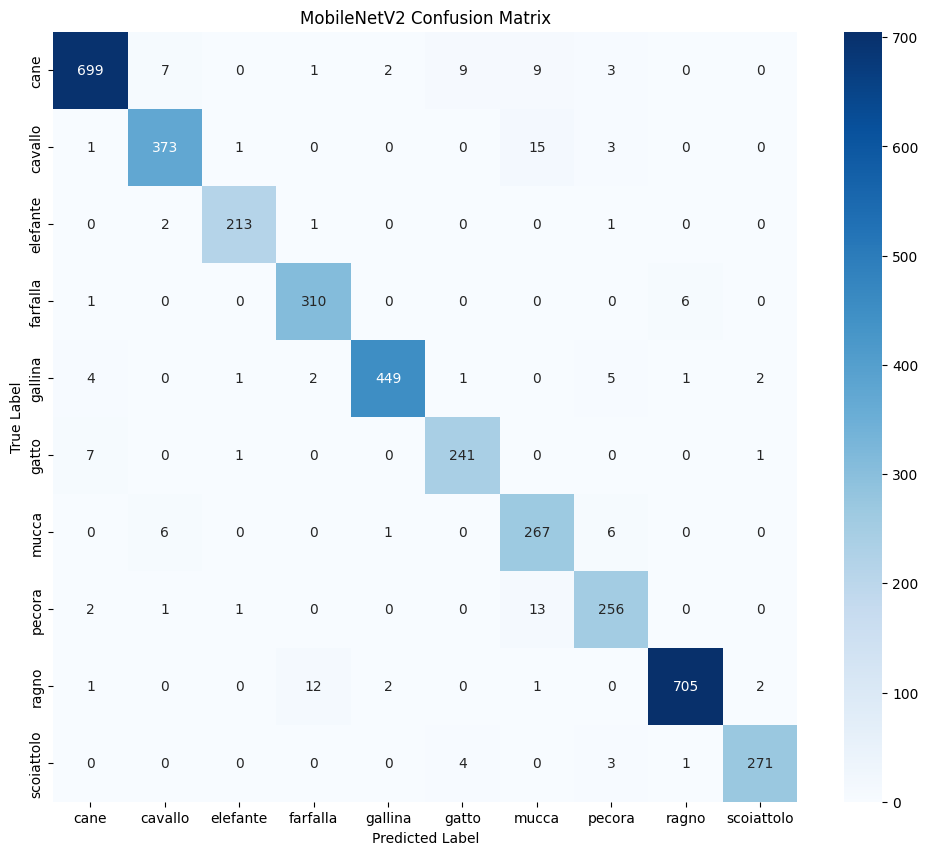

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix:")
cm_mobile = confusion_matrix(y_test, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

--- Training History (Fine-Tuning Stage) ---


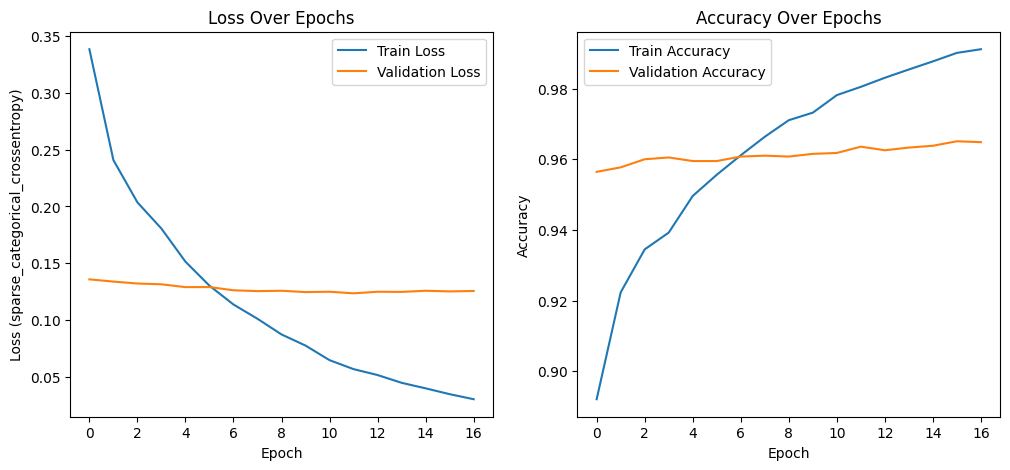

In [ ]:
import matplotlib.pyplot as plt


def plot_training_history(history):
    plt.figure(figsize=(12, 5))


    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (sparse_categorical_crossentropy)')
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

print("--- Training History (Fine-Tuning Stage) ---")
plot_training_history(history)

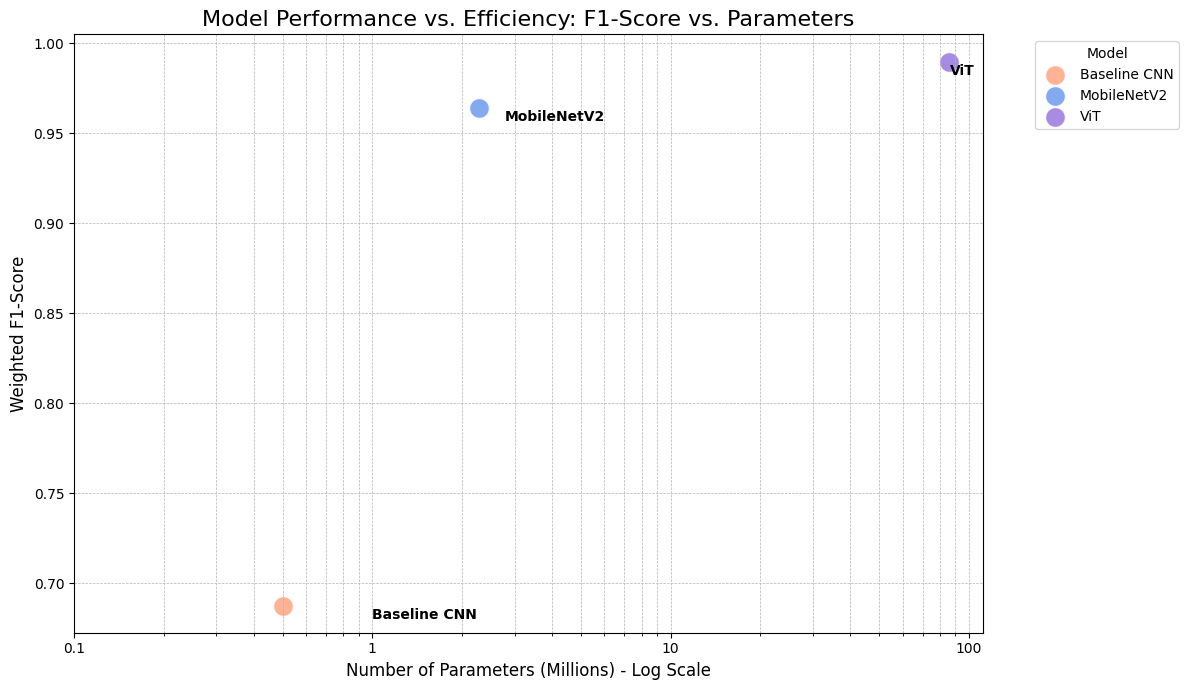

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline CNN', 'MobileNetV2', 'ViT']
f1_scores = [0.6875, 0.9638, 0.9898]


parameters_M = [0.5, 2.27, 86]


colors = ['#FFA07A', '#6495ED', '#9370DB']

plt.figure(figsize=(12, 7))


for i, model_name in enumerate(models):
    plt.scatter(parameters_M[i], f1_scores[i],
                s=200,
                color=colors[i],
                label=f'{model_name}',
                alpha=0.8,
                edgecolors='w',
                linewidth=0.8)


    plt.text(parameters_M[i] + 0.5, f1_scores[i] - 0.005,
             model_name, fontsize=10, ha='left', va='center', fontweight='bold', color='black')


plt.title('Model Performance vs. Efficiency: F1-Score vs. Parameters', fontsize=16)
plt.xlabel('Number of Parameters (Millions) - Log Scale', fontsize=12)
plt.ylabel('Weighted F1-Score', fontsize=12)


plt.xscale('log')
plt.xticks([0.1, 1, 10, 100], ['0.1', '1', '10', '100'])

plt.grid(True, which="both", ls="--", c='0.7', linewidth=0.5)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('performance_efficiency_scatter.png')
plt.show()

SyntaxError: keyword argument repeated: ha (2315150877.py, line 43)

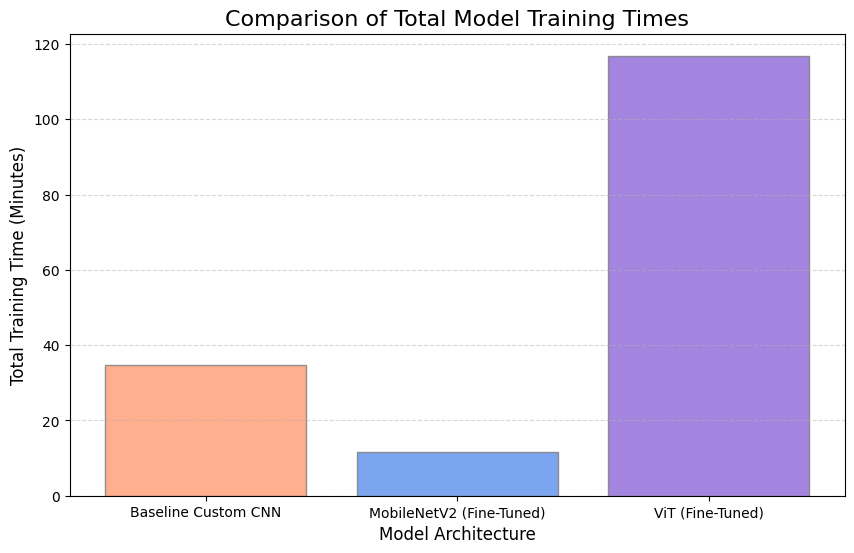

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ['Baseline Custom CNN', 'MobileNetV2 (Fine-Tuned)', 'ViT (Fine-Tuned)']


times_minutes = [
    34 + (40 / 60),
    11 + (31 / 60),
    (1 * 60) + 56 + (52 / 60) # ViT
]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FFA07A', '#6495ED', '#9370DB']
bars = ax.bar(models, times_minutes, color=colors, edgecolor='grey', alpha=0.85)


ax.set_title('Comparison of Total Model Training Times', fontsize=16)
ax.set_xlabel('Model Architecture', fontsize=12)
ax.set_ylabel('Total Training Time (Minutes)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(ha='center', rotation=15, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f'{height:.1f} min',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()

plt.show()